# Experiment 2 -- Composition and priority inversion on a symmetric ratio range

Vary the patient-to-impatient arrival ratio over **0.1 to 10** at fixed total
arrival rate. The reciprocal endpoints put equal log-axis width on either side
of equal population shares. All three panels use the entire declared domain.

This example isolates the both-served mechanism in the paper (Figure 7): giving the deeper
service to the minority saves capacity, so the majority receives shallower service
and priority. With the delay sensitivities of Experiment 1 and total arrival rate
2.5, the allocation switches just above ratio one. Exclusion is studied in Experiment 1; it is not asserted
for this composition example.

## Queueing model and optimization scope

Independent Poisson arrivals join one server. A served job draws its service
requirement from the **empirical distribution at its assigned depth**, independently
of delay sensitivity. Service requirements are proportional to historical token
cost, with the same common normalization as `DeepSWE_stats.ipynb`; they are not
measured seconds. Service value is the empirical binary success rate. A no-service
assignment has value, service time, and sojourn time zero.

With potential type arrival rates $\lambda_i$, set
$\rho_i=\lambda_i m_i$, $\rho=\sum_i\rho_i$, and
$R=\tfrac12\sum_i\lambda_i E[S_i^2]$. Reject assignments with $\rho\geq1$.
For FCFS, $w_i=m_i+R/(1-\rho)$ for served types. For nonpreemptive priority,

$$w_i=m_i+\frac{R}{(1-H_i)(1-H_i-\rho_i)},$$

where $H_i$ is the load of higher-priority classes. Welfare per unit time is
$W=\sum_i\lambda_i[V(d_i)-\theta_i w_i]$. No monetary cost is subtracted a
second time. These are **exact stationary calculations under the specified
queueing assumptions**, not queue simulations or an exponential approximation.

IC requires sojourn to be nonincreasing in $\theta$, **including excluded types**.
We also construct prices and check every pairwise deviation and the outside option.
The analysis follows the paper's transferable-price formulation; a new restriction
on prices would require re-solving the menu problem.

This notebook is self-contained. Run its cells from top to bottom; only the
saved files in `data/` are required. Calibration, queueing formulas, optimization,
plotting, and numerical checks are included below. No additional local Python
modules or API calls are needed. Snapshot checksums are checked on every run.

For each parameter point, exhaustively evaluate **86 distinct policies**:
25 positive-depth pairs with either strict priority order or FCFS, 10 assignments
serving only one type, and closure. Both the centralized optimum and IC optimum
are exact **within these deterministic scheduling choices**.
We do not optimize mixtures of priority rules or randomized depths.
Exclusion is reported as exclusion, not called a priority reversal.

The delay sensitivities and demand parameters below are **illustrative**, selected
to expose the mechanisms; they are not estimated from the benchmark. Trial outcomes
and service costs have not been altered to obtain these patterns. Regime endpoints
are reported at the resolution of the plotted parameter grid.

## Load the empirical calibration

All five depths use one common cost-to-time scaling factor. The loader verifies the saved data before computing service values and moments.


In [1]:
from pathlib import Path
from dataclasses import dataclass
from itertools import combinations, product, permutations
import hashlib
import json
import math

import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# Launch from this folder, Code/, or the repository root.
ROOT = next((p for p in [Path.cwd(), Path.cwd() / 'Case Study DeepSWE',
                       Path.cwd() / 'Code/Case Study DeepSWE']
             if (p / 'data/manifest.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Launch from the notebook folder, Code/, or the repository root.')
RESULTS = ROOT / 'results'  # Figures used in the paper.

LABELS = np.array(['No service', 'low', 'medium', 'high', 'xhigh', 'max'])

COLORS = {'central': '#4c78a8', 'ic': '#e15759', 'joint': '#4c78a8',
          'depth': '#59a14f', 'priority': '#f28e2b', 'neither': '#777777'}


@dataclass
class Calibration:
    values: np.ndarray
    means: np.ndarray
    seconds: np.ndarray
    samples: dict
    scale: float
    provenance: dict


def load_calibration():
    """Recompute Sol's moments from checksum-verified trial-level snapshots."""
    manifest = json.loads((ROOT / 'data/manifest.json').read_text(encoding='utf-8'))
    records = []
    for entry in [manifest, *manifest['supplemental_files']]:
        raw = (ROOT / 'data' / entry['file']).read_bytes()
        if hashlib.sha256(raw).hexdigest() != entry['sha256']:
            raise ValueError(f"Snapshot checksum mismatch: {entry['file']}")
        part = json.loads(raw.decode('utf-8-sig'))
        assert len(part) == entry['record_count']
        records.extend(part)
    records = [r for r in records if r['model'] == 'gpt-5-6-sol']
    assert len(records) == 2260 and len({r['trial_name'] for r in records}) == 2260
    excluded = [r for r in records if not r['included_in_score']]
    assert len(excluded) == 4
    assert all(r['error_category'] == 'verifier_timeout' for r in excluded)
    scale = 1 / np.mean([r['cost_usd'] for r in records])
    values, means, seconds, samples = [0.], [0.], [0.], {}
    for effort in LABELS[1:]:
        rows = [r for r in records if r['reasoning_effort'] == effort]
        assert len(rows) == 452
        tasks, repeats = np.unique([r['task_name'] for r in rows], return_counts=True)
        assert len(tasks) == 113 and np.all(repeats == 4)
        times = scale * np.array([r['cost_usd'] for r in rows])
        assert np.all(np.isfinite(times)) and np.all(times > 0)
        samples[effort] = times
        values.append(np.mean([int(r['passed']) if r['included_in_score'] else 0 for r in rows]))
        means.append(times.mean())
        seconds.append(np.mean(times ** 2))
    assert np.isclose(np.concatenate(list(samples.values())).mean(), 1)
    provenance = {'model': 'gpt-5-6-sol', 'trials': len(records),
                  'timeout_as_incorrect': 4, 'cost_to_time': scale,
                  'snapshots': [{'file': e['file'], 'sha256': e['sha256']}
                                for e in [manifest, *manifest['supplemental_files']]]}
    return Calibration(np.array(values), np.array(means), np.array(seconds),
                       samples, scale, provenance)


cal = load_calibration()
print('GPT-5.6 Sol: 113 tasks x 4 trials x 5 efforts; four verifier timeouts counted incorrect.')
print(f'One common cost-to-time factor: {cal.scale:.8f}; pooled mean service time = 1.')
print(f"{'Depth':<12} {'Value':>9} {'E[S]':>10} {'E[S^2]':>10}")
for name, v, m, b in zip(LABELS, cal.values, cal.means, cal.seconds):
    print(f'{name:<12} {v:9.4f} {m:10.4f} {b:10.4f}')


GPT-5.6 Sol: 113 tasks x 4 trials x 5 efforts; four verifier timeouts counted incorrect.
One common cost-to-time factor: 0.25665713; pooled mean service time = 1.
Depth            Value       E[S]     E[S^2]
No service      0.0000     0.0000     0.0000
low             0.4535     0.2757     0.0943
medium          0.6106     0.4779     0.2973
high            0.6925     0.8899     1.0087
xhigh           0.7058     1.2082     1.8421
max             0.7235     2.1482     6.6322


## Queue evaluation and incentive compatibility

The functions below implement the formulas above. Excluded types remain in the incentive checks.


In [2]:
def evaluate(cal, depths, rates, theta, rule='priority', order=None):
    """Evaluate a stable static policy. Rates refer to potential arrivals.

    rule='priority': descending theta/E[S] unless an explicit order is supplied.
    rule='fcfs': a single FCFS queue. Excluded types have value and sojourn zero.
    Returns None for instability. Priority is nonpreemptive, FCFS within class.
    """
    depths = np.asarray(depths, dtype=int)
    rates, theta = np.asarray(rates, dtype=float), np.asarray(theta, dtype=float)
    assert depths.shape == rates.shape == theta.shape
    assert np.all((depths >= 0) & (depths <= 5))
    assert np.all(rates >= 0) and np.all(theta >= 0)
    m, b, v = cal.means[depths], cal.seconds[depths], cal.values[depths]
    rho = rates * m
    total = rho.sum()
    if total >= 1:
        return None
    residual = .5 * np.dot(rates, b)
    served = depths > 0
    w = np.zeros(len(depths))
    if rule == 'fcfs':
        w[served] = m[served] + residual / (1 - total)
    elif rule == 'priority':
        if order is None:
            idx = np.flatnonzero(served)
            order = idx[np.argsort(-theta[idx] / m[idx], kind='stable')]
        else:
            order = np.array([i for i in order if served[i]], dtype=int)
            assert sorted(order.tolist()) == np.flatnonzero(served).tolist()
        cumulative = np.cumsum(rho[order])
        previous = cumulative - rho[order]
        w[order] = m[order] + residual / ((1 - previous) * (1 - cumulative))
    else:
        raise ValueError('rule must be fcfs or priority')
    return {'welfare': float(np.dot(rates, v - theta * w)), 'sojourn': w,
            'depths': depths.copy(), 'rho': float(total), 'rule': rule}


def is_ic(theta, sojourn, tol=1e-10):
    """Single crossing: sojourn must be nonincreasing in delay sensitivity.

    Includes outside-option assignments. Assumes distinct theta, as in notebooks.
    """
    return bool(np.all(np.diff(np.asarray(sojourn)[np.argsort(theta)]) <= tol))


def price_certificate(cal, depths, theta, sojourn):
    """Construct prices and verify all pairwise IC and individual rationality.

    The highest-theta type gets zero surplus; discrete envelope increments use
    the next type's sojourn. Transfers follow the paper's unrestricted prices.
    A separate outside option is always included in the deviation check.
    """
    theta, sojourn = np.asarray(theta), np.asarray(sojourn)
    if not is_ic(theta, sojourn):
        raise ValueError('Sojourn allocation is not incentive compatible')
    idx = np.argsort(theta)
    t, w = theta[idx], sojourn[idx]
    surplus = np.zeros(len(t))
    for i in range(len(t) - 2, -1, -1):
        surplus[i] = surplus[i + 1] + (t[i + 1] - t[i]) * w[i + 1]
    prices = np.empty(len(t))
    prices[idx] = cal.values[np.asarray(depths)[idx]] - t * w - surplus
    utility = cal.values[depths][None, :] - theta[:, None] * sojourn[None, :] - prices[None, :]
    truthful = np.diag(utility)
    regret = np.maximum(0, np.maximum(utility.max(axis=1), 0) - truthful)
    assert regret.max() < 1e-9 and truthful.min() > -1e-9
    assert np.allclose(prices[np.asarray(depths) == 0], 0)
    return {'prices': prices, 'surplus': truthful, 'max_regret': float(regret.max())}


## Policy optimization

The optimizer enumerates the policy class stated above. Its definitions are included here so this notebook runs independently.


In [3]:
TWO_POLICIES = [(a, b, rule) for a, b in product(range(6), repeat=2)
                for rule in (('impatient', 'patient', 'fcfs') if a and b else ('fcfs',))]


def two_type_sweep(cal, arrivals, impatient_shares, theta):
    """Exhaustive optimization of all 86 deterministic policies at every point.

    theta=[impatient, patient]. IC optimum is over the same three scheduling
    choices (no randomized mixtures of priority disciplines).
    """
    arrivals, shares = np.broadcast_arrays(np.atleast_1d(arrivals), np.atleast_1d(impatient_shares))
    theta = np.asarray(theta)
    assert theta[0] > theta[1] >= 0
    assert np.all(arrivals > 0) and np.all((shares > 0) & (shares < 1))
    rates = arrivals[:, None] * np.column_stack([shares, 1 - shares])
    welfare = np.full((len(arrivals), 86), -np.inf)
    times = np.zeros((len(arrivals), 86, 2))
    for j, (a, b, rule) in enumerate(TWO_POLICIES):
        d = np.array([a, b]); m = cal.means[d]
        rho = rates * m; total = rho.sum(axis=1)
        ok = total < 1
        r, rt = rho[ok], rates[ok]
        residual = .5 * (rt @ cal.seconds[d])
        w = np.zeros((ok.sum(), 2))
        if rule == 'fcfs':
            w[:, d > 0] = m[d > 0] + residual[:, None] / (1 - total[ok, None])
        else:
            h, l = (0, 1) if rule == 'impatient' else (1, 0)
            w[:, h] = m[h] + residual / (1 - r[:, h])
            w[:, l] = m[l] + residual / ((1 - r[:, h]) * (1 - total[ok]))
        welfare[ok, j] = np.sum(rt * (cal.values[d] - theta * w), axis=1)
        times[ok, j] = w
    feasible_ic = times[:, :, 0] <= times[:, :, 1] + 1e-10
    best = {}
    for key, scores in [('central', welfare), ('ic', np.where(feasible_ic, welfare, -np.inf))]:
        winners = scores.argmax(axis=1)
        chosen = [TWO_POLICIES[j] for j in winners]
        best[key] = {'welfare': scores[np.arange(len(arrivals)), winners],
                     'depths': np.array([p[:2] for p in chosen]),
                     'rules': np.array([p[2] for p in chosen]),
                     'sojourn': times[np.arange(len(arrivals)), winners],
                     'policy_index': winners}
    assert np.all(best['central']['welfare'] + 1e-10 >= best['ic']['welfare'])
    return best


## Numerical checks

Check queue identities and compare the optimizer with direct scalar enumeration on a small instance before running the experiment.


In [4]:
# Independent M/M/1 check: exponential mean 2, arrival .2 => mean sojourn 2/(1-.4).
example = Calibration(np.array([0., 1.]), np.array([0., 2.]), np.array([0., 8.]), {}, 1., {})
for rule in ['fcfs', 'priority']:
    result = evaluate(example, [1, 0], [.2, 100.], [.3, .1], rule)
    np.testing.assert_allclose(result['sojourn'], [2 / .6, 0.])
    assert evaluate(example, [1], [.5], [.1], rule) is None

# Conservation of load-weighted waiting, and c-mu optimality among all six orders.
d = np.array([1, 3, 2])
rates, theta_check = np.array([.2, .25, .3]), np.array([.1, .05, .2])
rho = rates * cal.means[d]
residual = .5 * np.dot(rates, cal.seconds[d])
expected = residual * rho.sum() / (1 - rho.sum())
best = evaluate(cal, d, rates, theta_check)
for order in permutations(range(3)):
    result = evaluate(cal, d, rates, theta_check, order=order)
    assert np.isclose(np.dot(rho, result['sojourn'] - cal.means[d]), expected)
    assert best['welfare'] + 1e-12 >= result['welfare']
assert not is_ic([.12, .09], [1., 0.])  # Patient excluded, impatient served: not IC.
assert is_ic([.12, .09], [0., 1.])
print('Queue formula, stability, priority, and outside-option checks passed.')

# Check the vectorized two-type calculation against scalar evaluation of all policies.
for lam_check in [.02, 3.5, 5.]:
    theta_check = np.array([.12, .09])
    sweep_check = two_type_sweep(cal, lam_check, .75, theta_check)
    scalar = []
    for a, b, rule in TWO_POLICIES:
        order = [0, 1] if rule == 'impatient' else [1, 0]
        result = evaluate(cal, [a, b], lam_check * np.array([.75, .25]), theta_check,
                          'fcfs' if rule == 'fcfs' else 'priority', order)
        if result is not None:
            scalar.append(result)
    assert np.isclose(sweep_check['central']['welfare'][0], max(r['welfare'] for r in scalar))
    assert np.isclose(sweep_check['ic']['welfare'][0],
                      max(r['welfare'] for r in scalar if is_ic(theta_check, r['sojourn'])))
print('Two-type optimizer agrees with independent scalar enumeration.')


Queue formula, stability, priority, and outside-option checks passed.
Two-type optimizer agrees with independent scalar enumeration.


## Figure style

Separate 7.2-by-4.8-inch panels, serif fonts, black/red type curves, and depth
labels d0 through d5. Only the figures used in the paper are saved, as
PDFs in `results/`. Green shading denotes a shorter patient sojourn, including
no-service assignments; the printed regimes distinguish exclusion from
priority inversion when both types are served.


In [5]:
def intervals(x, mask):
    """Grid endpoints of connected true runs; not exact transition estimates."""
    mask = np.asarray(mask, dtype=bool)
    padded = np.r_[False, mask, False]
    starts = np.flatnonzero(np.diff(padded.astype(int)) == 1)
    ends = np.flatnonzero(np.diff(padded.astype(int)) == -1) - 1
    return [(float(x[a]), float(x[b])) for a, b in zip(starts, ends)]

RED = '#c0392b'
DESIGNS = {
    'joint': dict(color='#222222', linewidth=2.4, linestyle='-', label=r'Joint ($c\mu$ priority)'),
    'depth': dict(color='#1f77b4', linewidth=2.0, linestyle='-.', label='Depth only (FCFS)'),
    'priority': dict(color=RED, linewidth=2.0, linestyle='--', label=r'Priority only ($c\mu$ priority)'),
    'neither': dict(color='#2ca02c', linewidth=3.0, linestyle=':', label='Neither (FCFS)'),
}

def setup_style():
    plt.rcParams.update({'font.family': 'serif', 'font.size': 9, 'axes.labelsize': 10,
                         'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.linewidth': .6, 'lines.linewidth': 1.5})

def paper_axis(xlabel, ylabel=None, depths=False, columns=2):
    figure, axis = plt.subplots(figsize=(7.2, 4.8))
    axis.set_xlabel(xlabel, fontsize=24)
    axis.tick_params(labelsize=18)
    axis.grid(axis='y', alpha=.18)
    if depths:
        axis.set_ylim(-.4, 5.5)
        axis.set_yticks(range(6), [f'$d_{k}$' for k in range(6)])
    if ylabel is not None:
        axis.set_ylabel(ylabel, fontsize=26, rotation=0, labelpad=18)
        axis.yaxis.set_label_coords(-.2, .5)
    figure.subplots_adjust(left=.21 if ylabel else .13, right=.96,
                           top=.82 if columns == 2 else .87, bottom=.21)
    return figure, axis

def paper_legend(axis, columns=2, fontsize=14):
    axis.legend(fontsize=fontsize, loc='lower center', bbox_to_anchor=(.5, 1.01),
                ncol=columns, frameon=True, edgecolor='#cccccc', framealpha=1.,
                handlelength=1.6, borderpad=.4, columnspacing=1.2)

def save_figure(figure, name):
    """Save a figure used in the paper as results/<name>.pdf, then display it."""
    RESULTS.mkdir(exist_ok=True)
    figure.savefig(RESULTS / f'{name}.pdf', metadata={'CreationDate': None})
    plt.show()
    plt.close(figure)

def shade_patient_advantage(axis, x, sojourn):
    # Shade where the patient type has the shorter sojourn time.
    mask = sojourn[:, 1] < sojourn[:, 0] - 1e-10
    for index, (left, right) in enumerate(intervals(x, mask)):
        axis.axvspan(left, right, color='#c7e9c0', alpha=.6, linewidth=0,
                     label=r'$w_2<w_1$' if index == 0 else None)

def regime_rows(x, result):
    states = list(zip(result['depths'][:, 0], result['depths'][:, 1], result['rules']))
    rows, start = [], 0
    for i in range(1, len(x) + 1):
        if i == len(x) or states[i] != states[start]:
            a, b, rule = states[start]
            rows.append({'left': x[start], 'right': x[i - 1],
                         'impatient_depth': a, 'patient_depth': b, 'rule': rule})
            start = i
    return rows


## Parameters and design rationale

Set $\lambda=2.5$, $\theta_1=0.030$, and $\theta_2=0.0225$, the delay sensitivities
of Experiment 1. If everyone received medium effort, utilization would exceed one;
if everyone received low effort, utilization would be below one. The optimum
therefore trades off the population receiving medium effort against congestion.
The displayed ratio range is fixed symmetrically at $[0.1,10]$, not cropped
around the reversal.

The total arrival rate was selected by scanning $\lambda\in[0.5,4]$ at these delay
sensitivities for a both-served majority/minority depth exchange close to ratio
one. The verification section perturbs both load and sensitivity contrast. A wider
reciprocal range $[0.01,100]$ is also reported to make behavior outside the figure
available. No claim of a universal single threshold is made outside the figure.

In [6]:
THETA = np.array([0.030, 0.0225])  # impatient, patient; as in Experiment 1
ARRIVAL = 2.5
RATIOS = np.logspace(-1., 1., 2001)
FULL_RATIOS = np.logspace(-2., 2., 4001)
setup_style()
results = two_type_sweep(cal, ARRIVAL, 1 / (1 + RATIOS), THETA)
full_results = two_type_sweep(cal, ARRIVAL, 1 / (1 + FULL_RATIOS), THETA)
central, menu = results['central'], results['ic']
X = RATIOS
reversal = (central['depths'].min(axis=1) > 0) & (central['rules'] == 'patient')
gap = (central['welfare'] - menu['welfare']) / central['welfare']
assert np.isclose(X[0] * X[-1], 1.) and np.isclose(X[len(X)//2], 1.)
assert np.all(central['depths'] > 0)
assert np.all(central['depths'][reversal] == [2, 1])
assert np.all(central['rules'][~reversal] == 'impatient')
assert {tuple(d) for d in central['depths'][~reversal]} == {(1, 2), (1, 1)}
assert len(intervals(X, reversal)) == 1 and not reversal[0] and reversal[-1]
assert X[reversal][0] > 1
print('Patient priority with both types served:', intervals(X, reversal))
print(f'Peak IC welfare loss: {gap.max():.2%} at ratio {X[gap.argmax()]:.3f}')
print(f'All-medium utilization={ARRIVAL * cal.means[2]:.3f}; all-low={ARRIVAL * cal.means[1]:.3f}')

Patient priority with both types served: [(1.0990058394325208, 10.0)]
Peak IC welfare loss: 3.28% at ratio 1.274
All-medium utilization=1.195; all-low=0.689


## Centralized depth assignment

Green shading marks $w_2<w_1$. When both depths are positive, the rule column
in the exported regime table identifies actual patient priority. A depth of
$d_0$ means no service, not successful instantaneous processing.


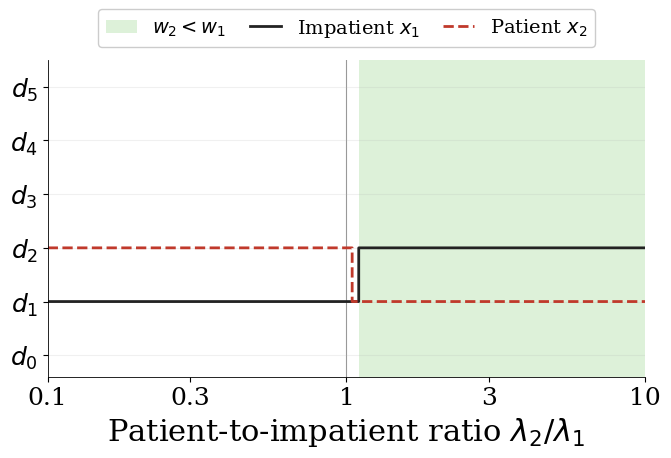

In [7]:
figure, axis = paper_axis(r'Patient-to-impatient ratio $\lambda_2/\lambda_1$', depths=True, columns=3)
axis.set_xscale('log')
axis.set_xticks([.1, .3, 1., 3., 10.], ['0.1', '0.3', '1', '3', '10'])
axis.axvline(1., color='#999999', linewidth=.8, zorder=0)
axis.minorticks_off()
axis.xaxis.label.set_size(22)
shade_patient_advantage(axis, X, central['sojourn'])
axis.step(X, central['depths'][:, 0], where='post', color='#222222', linewidth=2., label=r'Impatient $x_1$')
axis.step(X, central['depths'][:, 1], where='post', color=RED, linestyle='--', linewidth=2., label=r'Patient $x_2$')
axis.set_xlim(X[0], X[-1])
paper_legend(axis, columns=3, fontsize=14)
save_figure(figure, 'two_type_composition_policy')

## Optimal IC menu


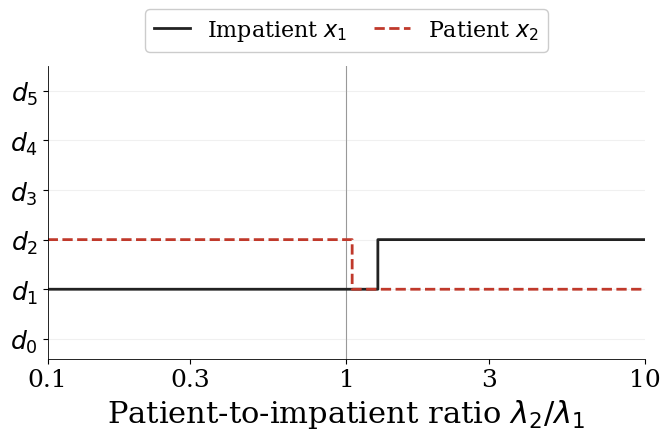

In [8]:
figure, axis = paper_axis(r'Patient-to-impatient ratio $\lambda_2/\lambda_1$', depths=True)
axis.set_xscale('log')
axis.set_xticks([.1, .3, 1., 3., 10.], ['0.1', '0.3', '1', '3', '10'])
axis.axvline(1., color='#999999', linewidth=.8, zorder=0)
axis.minorticks_off()
axis.xaxis.label.set_size(22)
axis.step(X, menu['depths'][:, 0], where='post', color='#222222', linewidth=2., label=r'Impatient $x_1$')
axis.step(X, menu['depths'][:, 1], where='post', color=RED, linestyle='--', linewidth=2., label=r'Patient $x_2$')
axis.set_xlim(X[0], X[-1])
paper_legend(axis, fontsize=16)
save_figure(figure, 'two_type_composition_policy_ic')

## Welfare


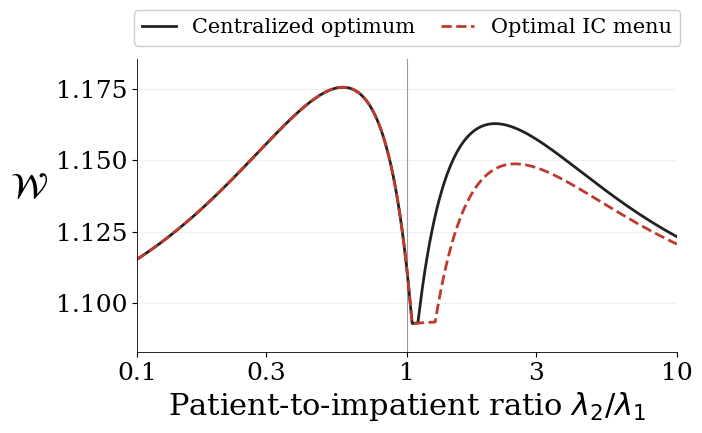

In [9]:
figure, axis = paper_axis(r'Patient-to-impatient ratio $\lambda_2/\lambda_1$', ylabel=r'$\mathcal{W}$')
axis.set_xscale('log')
axis.set_xticks([.1, .3, 1., 3., 10.], ['0.1', '0.3', '1', '3', '10'])
axis.axvline(1., color='#999999', linewidth=.8, zorder=0)
axis.minorticks_off()
axis.xaxis.label.set_size(22)
axis.plot(X, central['welfare'], color='#222222', linewidth=2., label='Centralized optimum')
axis.plot(X, menu['welfare'], color=RED, linestyle='--', linewidth=2., label='Optimal IC menu')
axis.set_xlim(X[0], X[-1])
paper_legend(axis, fontsize=15)

lo = min(central['welfare'].min(), menu['welfare'].min())
hi = max(central['welfare'].max(), menu['welfare'].max())
axis.set_ylim(lo - .12 * (hi - lo), hi + .12 * (hi - lo))
save_figure(figure, 'two_type_composition_welfare')

## Regimes and validation

The output lists the regimes of the centralized optimum and the optimal IC menu
on the displayed range, and the centralized regimes on the wider range
$[0.01,100]$. Within the displayed reversal, the patient majority receives
shallower service and priority; IC forces a different allocation.


In [10]:
regret = max(price_certificate(cal, d, THETA, w)['max_regret']
             for d, w in zip(full_results['ic']['depths'], full_results['ic']['sojourn']))
print(f'Maximum IC regret of the optimal menus: {regret:.2e}')
for label, x, result in [('Centralized optimum', X, central), ('Optimal IC menu', X, menu),
                         ('Centralized optimum, ratio range [0.01, 100]', FULL_RATIOS, full_results['central'])]:
    print(f'{label}:')
    for row in regime_rows(x, result):
        print(f"  [{row['left']:.3f}, {row['right']:.3f}]: "
              f"d1={row['impatient_depth']}, d2={row['patient_depth']}, {row['rule']}")
for arrival in [2.45, 2.50, 2.55]:
    for contrast in [1.30, 4 / 3, 1.37]:
        trial = two_type_sweep(cal, arrival, 1 / (1 + X), [.0225 * contrast, .0225])
        cc, mm = trial['central'], trial['ic']
        reverse = (cc['depths'].min(axis=1) > 0) & (cc['rules'] == 'patient')
        spans = intervals(X, reverse)
        assert np.all(cc['depths'] > 0) and len(spans) == 1
        assert not reverse[0] and reverse[-1] and spans[0][0] > 1
        loss = np.max((cc['welfare'] - mm['welfare']) / cc['welfare'])
        print(f'Arrival {arrival:.2f}, sensitivity ratio {contrast:.2f}: '
              f'patient priority on {spans}, peak gap={loss:.2%}')


Maximum IC regret of the optimal menus: 1.11e-16
Centralized optimum:
  [0.100, 1.042]: d1=1, d2=2, impatient
  [1.045, 1.096]: d1=1, d2=1, impatient
  [1.099, 10.000]: d1=2, d2=1, patient
Optimal IC menu:
  [0.100, 1.042]: d1=1, d2=2, impatient
  [1.045, 1.271]: d1=1, d2=1, impatient
  [1.274, 10.000]: d1=2, d2=1, impatient
Centralized optimum, ratio range [0.01, 100]:
  [0.010, 1.042]: d1=1, d2=2, impatient
  [1.045, 1.096]: d1=1, d2=1, impatient
  [1.099, 45.604]: d1=2, d2=1, patient
  [45.709, 100.000]: d1=3, d2=1, patient
Arrival 2.45, sensitivity ratio 1.30: patient priority on [(1.0914403364487566, 10.0)], peak gap=3.15%
Arrival 2.45, sensitivity ratio 1.33: patient priority on [(1.0990058394325208, 10.0)], peak gap=2.92%
Arrival 2.45, sensitivity ratio 1.37: patient priority on [(1.1091748152624008, 10.0)], peak gap=2.65%
Arrival 2.50, sensitivity ratio 1.30: patient priority on [(1.0839269140212033, 10.0)], peak gap=3.56%
Arrival 2.50, sensitivity ratio 1.33: patient priority 